In [1]:
import pandas as pd
import os
import ee
import geemap
import glob
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

In [2]:
ee.Authenticate() #Uncomment this whenever needed, once done usually not needed for 1-2 days
ee.Initialize(project='ee-apoorvadewan13')

In [5]:
CLASSES = ['tree', 'shrub']
YEARS   = list(range(2001, 2011))  # adjust as more years come in

def load_stability_csvs(cls_name, folder='./GEE_Stability'):
    yearly_dfs = []
    for year in YEARS:
        f = f"{folder}/stability_{cls_name}_{year}.csv"
        try:
            df = pd.read_csv(f)
        except FileNotFoundError:
            print(f"  Missing file: {f}")
            continue
        
        # round to fix floating point noise (e.g. 2.9999999987 → 3)
        df['cluster_id'] = pd.to_numeric(df['cluster_id'], errors='coerce').round()
        df = df.set_index('grid_id')['cluster_id'].rename(str(year))
        yearly_dfs.append(df)

    merged = pd.concat(yearly_dfs, axis=1)
    merged = merged.fillna(-1)
    print(f"[{cls_name}] merged shape: {merged.shape}")
    return merged

data = {}
for cls in CLASSES:
    data[cls] = load_stability_csvs(cls)

[tree] merged shape: (2256839, 10)
[shrub] merged shape: (2256839, 10)


tree: 1209451 grids with >=10 valid years


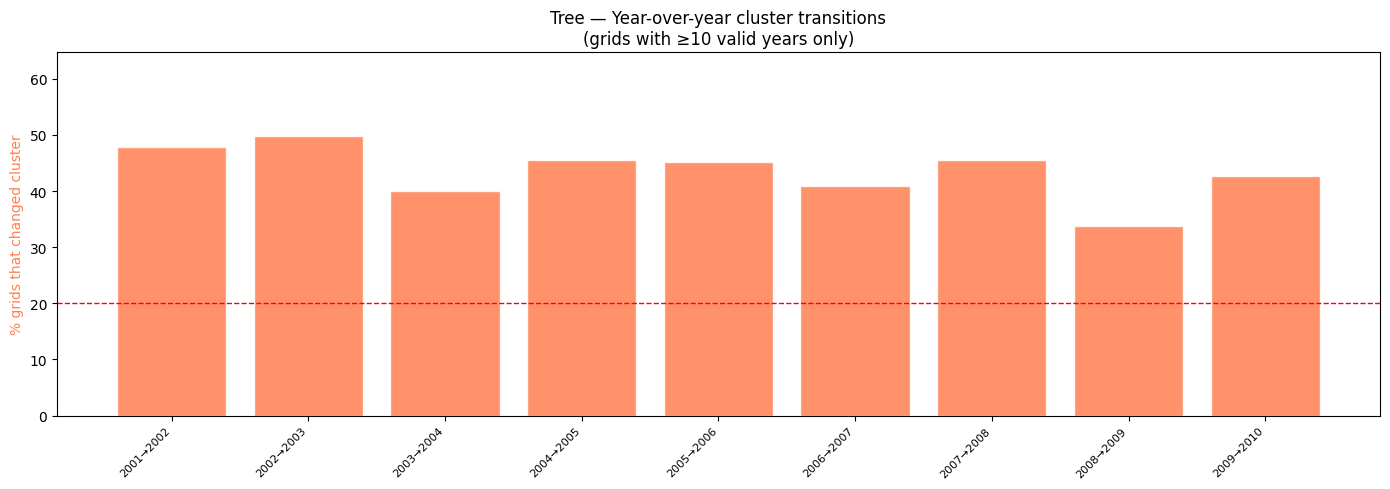

shrub: 602061 grids with >=10 valid years


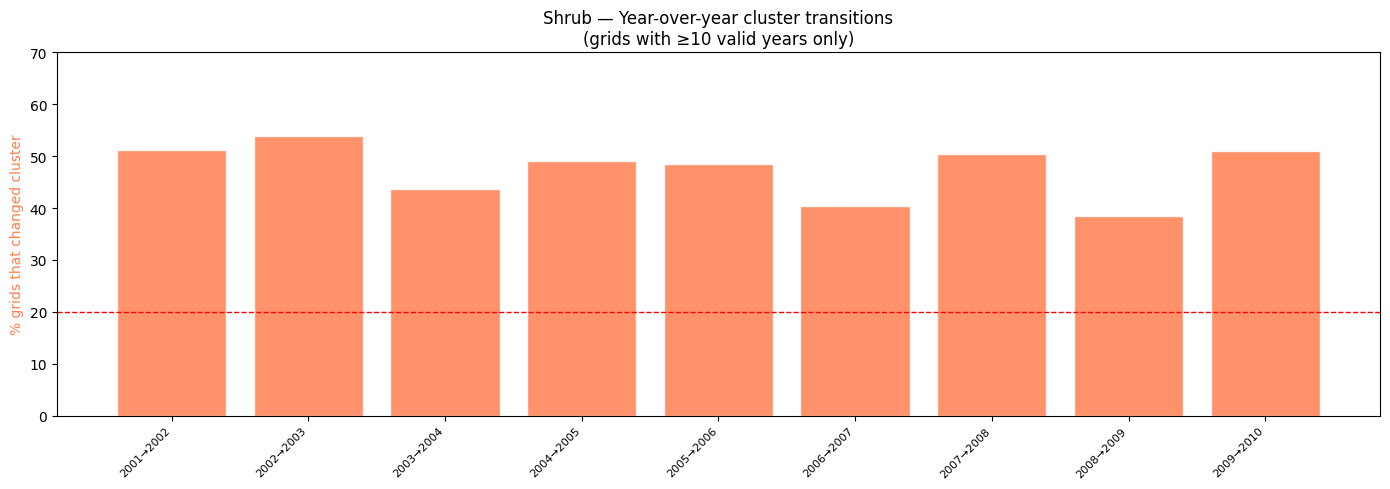

: 

In [ ]:
def plot_transitions(cls, min_valid_years=1):
    df        = data[cls].replace(-1, np.nan)
    year_cols = [str(y) for y in YEARS]

    # Only keep grids with at least min_valid_years of data
    n_valid = df.notna().sum(axis=1)
    df      = df[n_valid >= min_valid_years]
    print(f'{cls}: {len(df)} grids with >={min_valid_years} valid years')

    change_rates = []
    for i in range(len(year_cols) - 1):
        y1, y2 = year_cols[i], year_cols[i+1]
        both   = df[[y1, y2]].dropna()   # only grids valid in BOTH years
        if len(both) == 0:
            continue
        changed = (both[y1] != both[y2]).sum()
        total   = len(both)
        change_rates.append({
            'transition' : f'{y1}→{y2}',
            'pct_changed': round(changed / total * 100, 1),
            'n_grids'    : total           # useful to see how many grids each bar is based on
        })

    tr_df = pd.DataFrame(change_rates)

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Bar: % changed
    bars = ax1.bar(range(len(tr_df)), tr_df['pct_changed'],
                   color='coral', edgecolor='white', alpha=0.85, label='% changed')
    ax1.set_xticks(range(len(tr_df)))
    ax1.set_xticklabels(tr_df['transition'], rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('% grids that changed cluster', color='coral')
    ax1.set_ylim(0, max(tr_df['pct_changed']) * 1.3)
    ax1.axhline(20, color='red', linestyle='--', linewidth=1, label='20% reference line')

    # Secondary axis: number of grids per transition (data coverage check)
    # ax2 = ax1.twinx()
    # ax2.plot(range(len(tr_df)), tr_df['n_grids'],
    #          color='steelblue', linewidth=1.5, marker='o', markersize=3,
    #          label='# grids compared')
    # ax2.set_ylabel('# grids compared', color='steelblue')
    # ax2.yaxis.label.set_color('steelblue')

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    ax1.set_title(f'{cls.capitalize()} — Year-over-year cluster transitions\n'
                  f'(grids with ≥{min_valid_years} valid years only)')
    plt.tight_layout()
    plt.savefig(f'transitions_{cls}.png', dpi=150)
    plt.show()

for cls in CLASSES:
    plot_transitions(cls, min_valid_years=10)